In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee', 'vibrant'])

def create_divergence_boundary_plot(delta, omegas, bs):
    """
    Returns a matplotlib Figure and Axes containing the divergence boundary plot.
    """
    omega = np.linspace(0, omegas.max() * 1.05, 800)
    mask = delta * omega <= 1
    omega = omega[mask]
    boundary = (-1 + np.sqrt(1 - (delta * omega)**2)) / delta

    fig, ax = plt.subplots()
    ax.plot(omega, boundary, 'k-', lw=1, label=r'Boundary $p(\omega)$')

    n2 = len(bs) // 2
    ax.scatter(omegas[:n2], bs[:n2], s=6, alpha=0.6, label='Initial')
    ax.scatter(omegas[n2:], bs[n2:], s=6, alpha=0.3, label='Optimized')

    ax.set_xlabel(r'$\omega$ [rad/s]')
    ax.set_ylabel(r"$b_c - b'$")
    ax.grid(ls=':', lw=0.5)
    ax.legend(frameon=False)
    ax.tick_params(direction='in', top=True, right=True)
    fig.tight_layout()
    return fig, ax


In [2]:
delta = 1/8192

np.random.seed(42)
n = 200
sim_omegas = np.random.uniform(0, 0.9/delta, size=n)
p_sim = (-1 + np.sqrt(1 - (delta * sim_omegas)**2)) / delta

# Define a margin to offset the points visibly away
margin = 50 + np.random.uniform(-30, 30, size=n)

# Half below (stable, lower), half above (unstable, higher)
sim_bs = p_sim - np.abs(margin)  # stable
sim_bs[int(n/2):] = p_sim[int(n/2):] + np.abs(margin[int(n/2):])

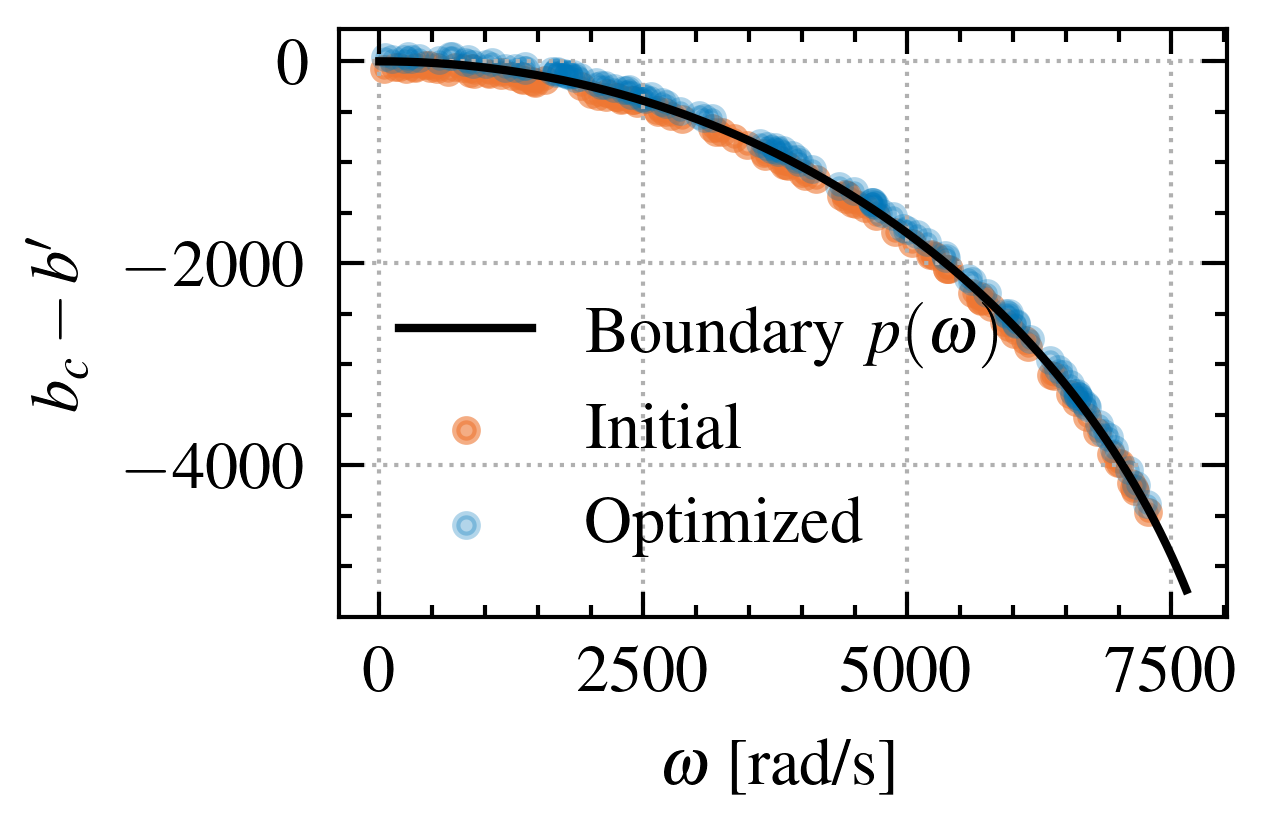

In [3]:
# Create plot (default size: ~6.5” × 4.2”)
fig, ax = create_divergence_boundary_plot(delta, sim_omegas, sim_bs)

# Resize for notebook display
fig.set_size_inches(2, 1.25)
plt.show()


In [4]:
import matplotlib.pyplot as plt

def set_size(width_pt, fraction=1, subplots=(1,1)):
    """Convert TeX pt-width to matplotlib inches, using golden-ratio height."""
    inches_per_pt = 1 / 72.27
    fig_width = width_pt * fraction * inches_per_pt
    golden = (5 ** .5 - 1) / 2
    fig_height = fig_width * golden * (subplots[0] / subplots[1])
    return (fig_width, fig_height)


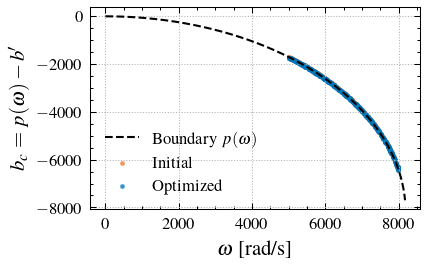

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from brf_lightning.utils.plot_defaults import new_figure, init_plot_style
from brf_lightning.utils.debuggin_plots import plot_stability

def simulate_points_near_and_below_boundary(
    n=500,
    delta=1/8192,
    omega_range=(5000, 8000),
    init_margin_mean=7.0,
    init_margin_std=1.5,
    opt_margin_extra=10.0,
    opt_margin_std=4.0
):
    """
    Simulates ω, b_c_init, and b_c_opt such that all are under the divergence boundary p(ω).
    Optimized points are more spread and deeper below.
    """
    # Frequencies (valid range)
    omegas = np.random.uniform(*omega_range, size=n)
    p = (-1 + np.sqrt(1 - (delta * omegas)**2)) / delta

    # Initial offsets: tightly near boundary (but under it)
    init_offset = np.abs(np.random.normal(init_margin_mean, init_margin_std, size=n))
    bc_init = p - init_offset

    # Optimized offsets: clearly deeper, more spread
    opt_offset = init_offset + np.abs(np.random.normal(opt_margin_extra, opt_margin_std, size=n))
    bc_opt = p - opt_offset

    return omegas, bc_init, bc_opt, p

init_plot_style()
fig, ax = new_figure(fraction=0.48)

omega, bc_init, bc_opt, p = simulate_points_near_and_below_boundary(
)

fig, ax = plot_stability(fig, ax, delta=1/8192, omegas=omega, bc_init=bc_init, bc_opt=bc_opt)
plt.show()
